Accuracy: 0.9209353167978525

Classification Report:
                 precision    recall  f1-score   support

            CDS       1.00      1.00      1.00    146888
 Selenocysteine       0.32      0.53      0.40        17
           exon       1.00      1.00      1.00    247262
 five_prime_utr       0.56      0.61      0.58     29628
           gene       1.00      1.00      1.00     11686
    start_codon       0.91      0.90      0.90     17151
     stop_codon       0.89      0.90      0.89     15566
three_prime_utr       0.63      0.62      0.63     28867
     transcript       0.62      0.59      0.61     40849

       accuracy                           0.92    537914
      macro avg       0.77      0.79      0.78    537914
   weighted avg       0.92      0.92      0.92    537914


Confusion Matrix:
[[146888      0      0      0      0      0      0      0      0]
 [     0      9      0      2      0      0      0      5      1]
 [     0      0 247262      0      0      0      0  

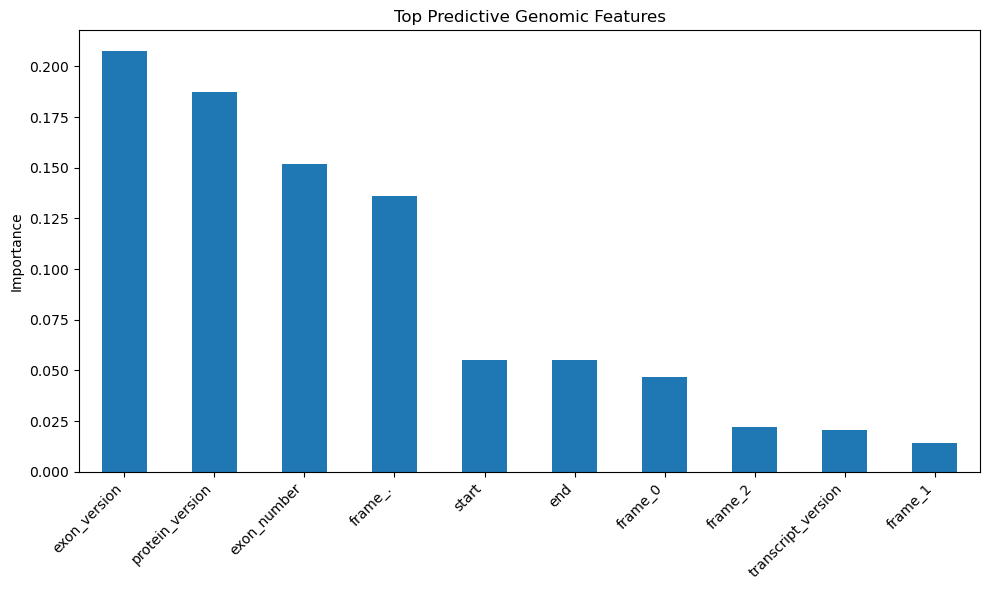

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

data = pd.read_csv("genomic_data.csv", low_memory=False, nrows=50000)

target_column = "feature"

columns_to_drop = [
    "seqname", "ccds_id", "exon_id", "gene_id", "gene_name", 
    "protein_id", "transcript_id", "transcript_name"
]
existing_columns_to_drop = [col for col in columns_to_drop if col in data.columns]
data_cleaned = data.drop(columns=existing_columns_to_drop)

X_raw = data_cleaned.drop(target_column, axis=1)
y = data_cleaned[target_column]

X = pd.get_dummies(X_raw)
X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nImportant Genomic Features:")
print(importance.head(10))

importance.head(10).plot(kind="bar", figsize=(10, 6))
plt.title("Top Predictive Genomic Features")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
